In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pg = pd.read_csv('/content/Customer Churn.csv')

In [ ]:
#replacing blanks with 0 becoause tenure its 0 that's why not total charges recorded

In [ ]:
pg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
pg.isna().sum()

In [ ]:
pg['TotalCharges'] = pg['TotalCharges'].replace(" ", "0")
pg['TotalCharges'] = pg['TotalCharges'].astype(float)

In [ ]:
pg.info()

In [ ]:
pg.describe()

In [ ]:
def conv(value):
  if value == 1:
    return 'yes'
  else:
    return 'no'
pg['SeniorCitizen'] = pg['SeniorCitizen'].apply(conv)

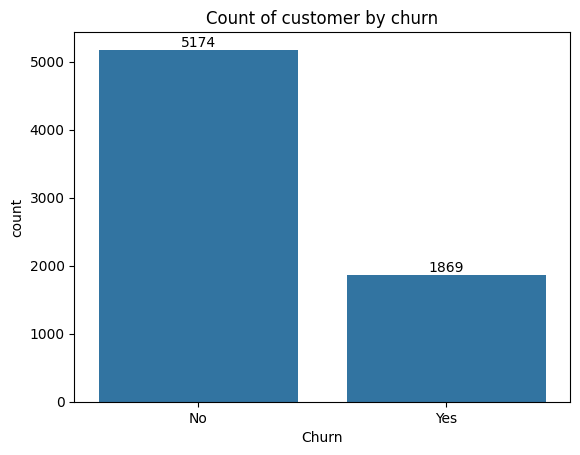

In [ ]:
ax = sns.countplot(x = 'Churn', data=pg)
plt.title('Count of customer by churn')
ax.bar_label(ax.containers[0])
plt.show()




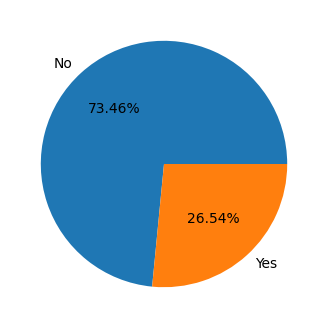

In [ ]:
plt.figure(figsize = (4,4))
gb = pg.groupby(['Churn']).agg({'Churn':'count'})
plt.pie(gb['Churn'], labels = gb.index, autopct = '%1.2f%%')
plt.show()

In [ ]:
# from this chart we can conclude 26.54% customer churned out # not lets explore the reason behind it

[Text(0, 0, '5901'), Text(0, 0, '1142')]

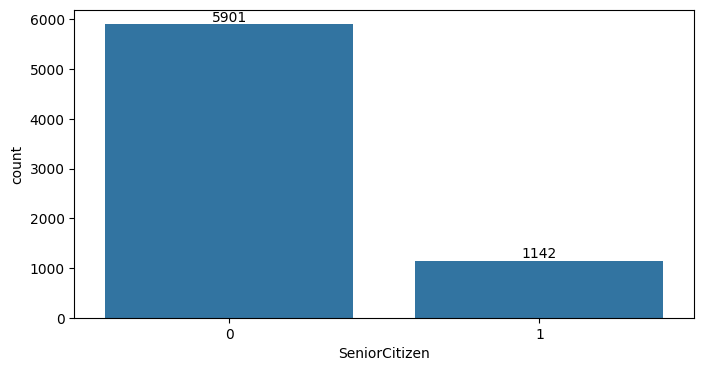

In [ ]:
plt.figure(figsize = (8,4))
ax = sns.countplot(x = 'SeniorCitizen', data=pg)
ax.bar_label(ax.containers[0])

[Text(0, 0, '2549'), Text(0, 0, '2625')]

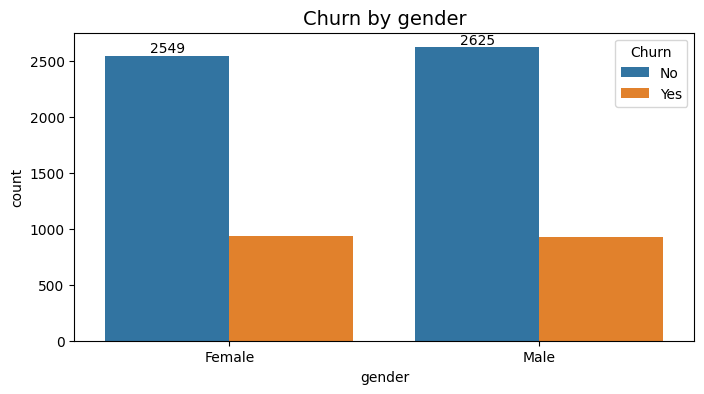

In [ ]:
plt.figure(figsize = (8,4))
plt.title('Churn by gender', fontsize = 14)
ax = sns.countplot(x = 'gender', data=pg, hue = 'Churn')
ax.bar_label(ax.containers[0])

[Text(0, 0, '1393'), Text(0, 0, '476')]

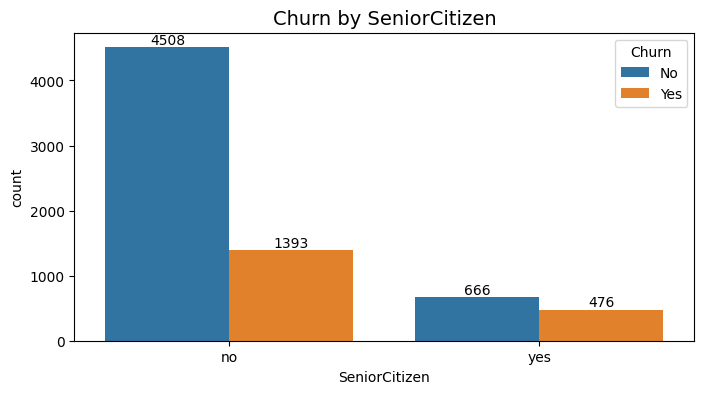

In [ ]:
plt.figure(figsize = (8,4))
plt.title('Churn by SeniorCitizen', fontsize = 14)
ax = sns.countplot(x = 'SeniorCitizen', data=pg, hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

<Figure size 800x400 with 0 Axes>

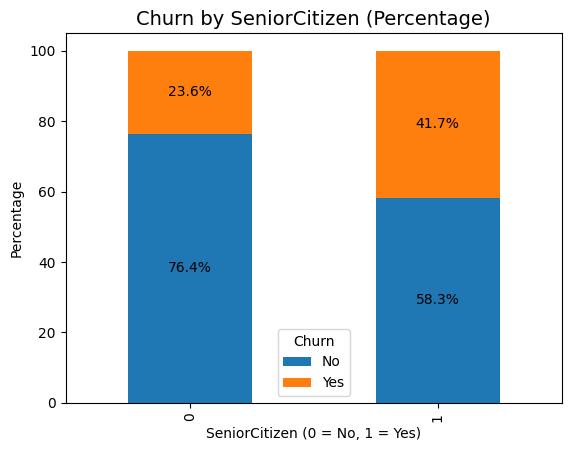

In [ ]:


# 1️⃣ Count data
churn_count = pd.crosstab(pg['SeniorCitizen'], pg['Churn'])

# 2️⃣ Convert to percentage (100% stacked)
churn_perc = churn_count.div(churn_count.sum(axis=1), axis=0) * 100

# 3️⃣ Plot stacked bar
plt.figure(figsize=(8,4))
ax = churn_perc.plot(kind='bar', stacked=True)

plt.title('Churn by SeniorCitizen (Percentage)', fontsize=14)
plt.xlabel('SeniorCitizen (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.legend(title='Churn')

# 4️⃣ Add percentage labels inside bars
for container in ax.containers:
    labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center')

plt.show()



In [ ]:
#comprative a greater percentage of people in senior citizen category have churned

<Axes: xlabel='tenure', ylabel='Count'>

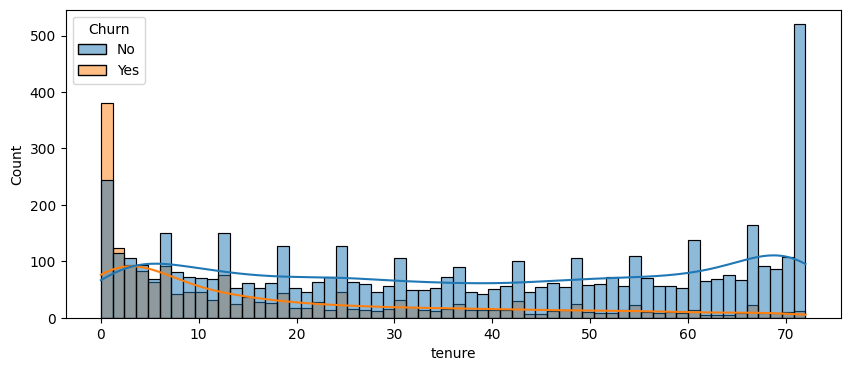

In [ ]:
plt.figure(figsize = (10,4))
sns.histplot(x = 'tenure', bins = 60, data=pg, kde = True, hue = 'Churn')

In [ ]:
#who people for long time our service using have stayed and
#people who used our service 1 month or 2 month this type maximum audience have churned out

[Text(0, 0, '3875'), Text(0, 0, '1473'), Text(0, 0, '1695')]

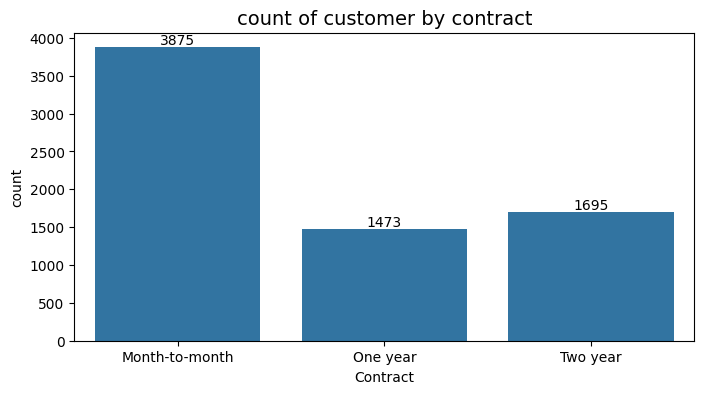

In [ ]:
plt.figure(figsize = (8,4))
plt.title('count of customer by contract', fontsize = 14)
ax = sns.countplot(x = 'Contract', data=pg)
ax.bar_label(ax.containers[0])

[Text(0, 0, '2220'), Text(0, 0, '1307'), Text(0, 0, '1647')]

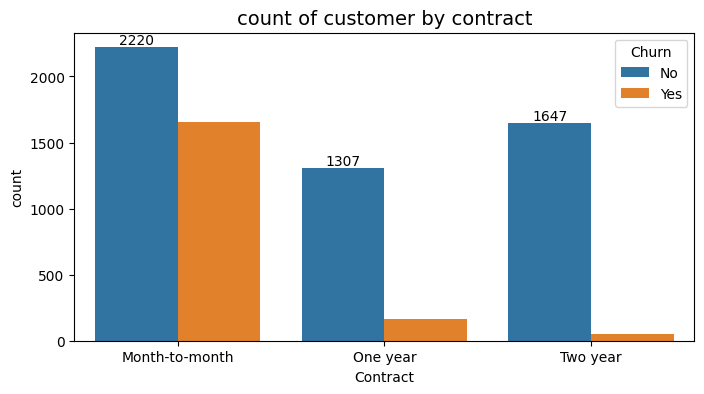

In [ ]:
plt.figure(figsize = (8,4))
plt.title('count of customer by contract', fontsize = 14)
ax = sns.countplot(x = 'Contract', data=pg, hue = 'Churn')
ax.bar_label(ax.containers[0])

In [ ]:
#people who have month to month contract enroll this type maximum
#people have churn out and other wise people who have enrolled on yearly basis this type people not churn

In [ ]:
pg.columns

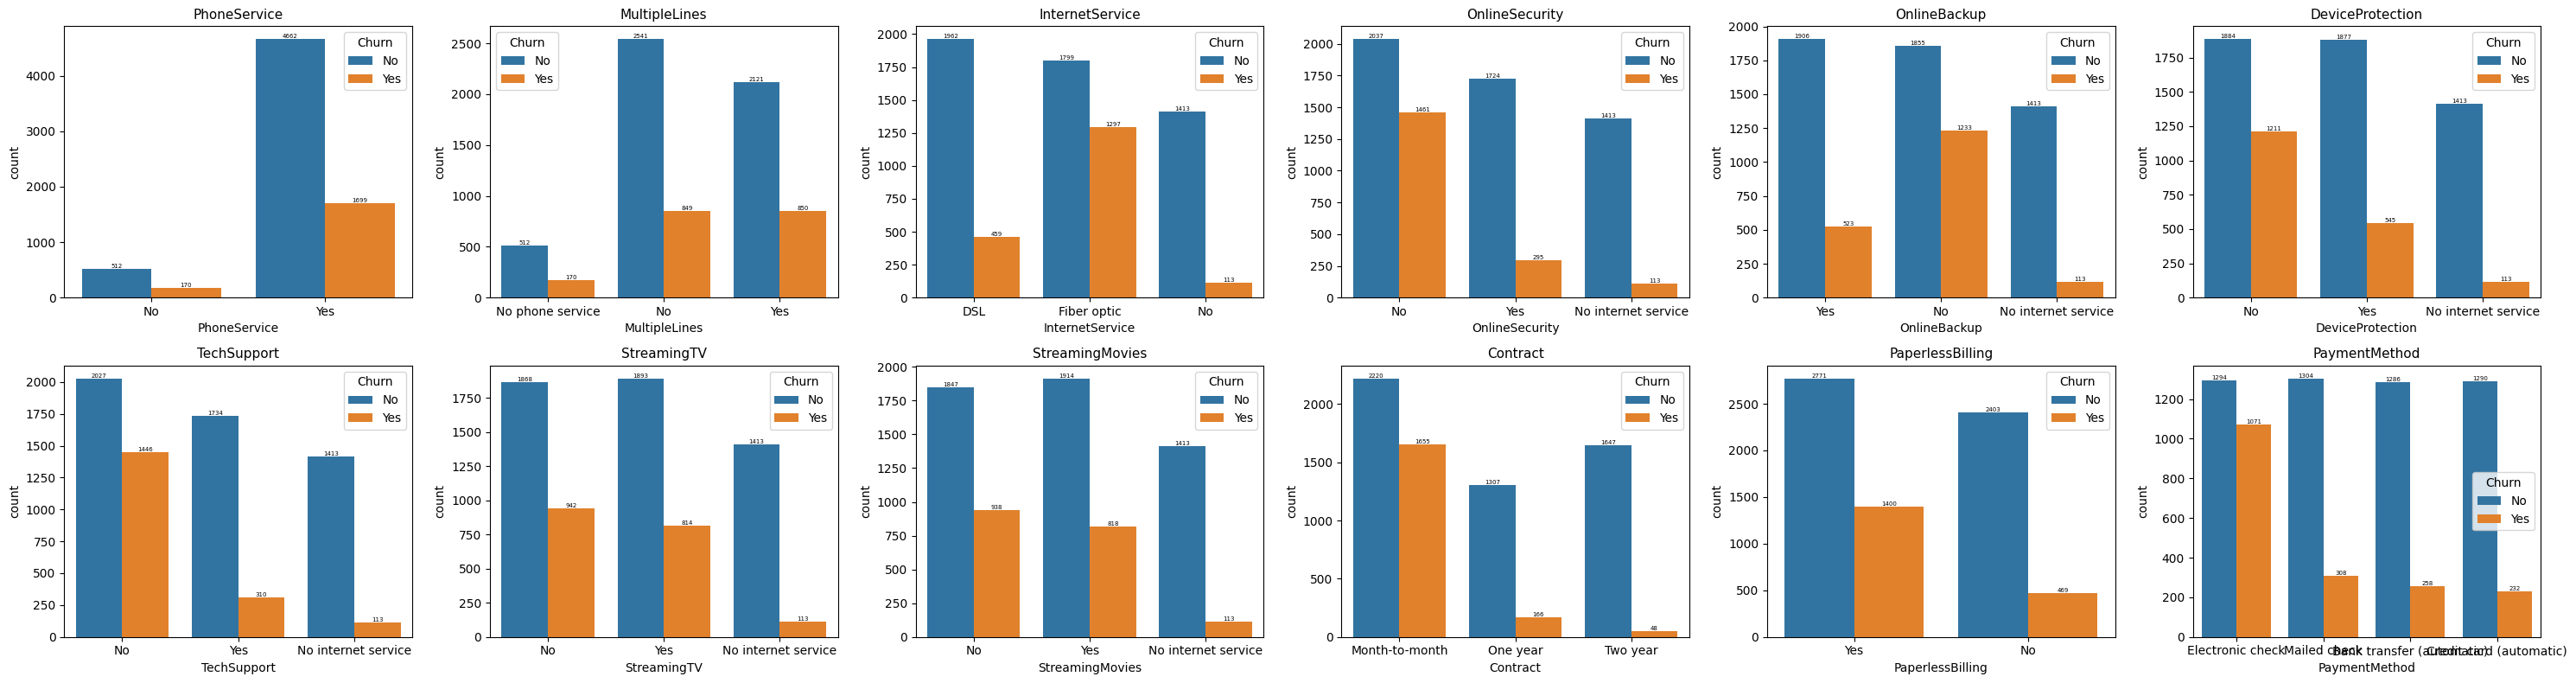

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# categorical columns
cat_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# layout calculation
n_cols = 6                     # plots per row
n_rows = math.ceil(len(cat_cols) / n_cols)

# figsize calculation (IMPORTANT PART)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 5, n_rows * 4)
)

axes = axes.flatten()

# plotting
for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(x=col, data=pg, ax=ax, hue = 'Churn')
    ax.set_title(col, fontsize=11)
    ax.tick_params(axis='x', rotation=0)

    # add labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=5)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Count of customer by payment method')

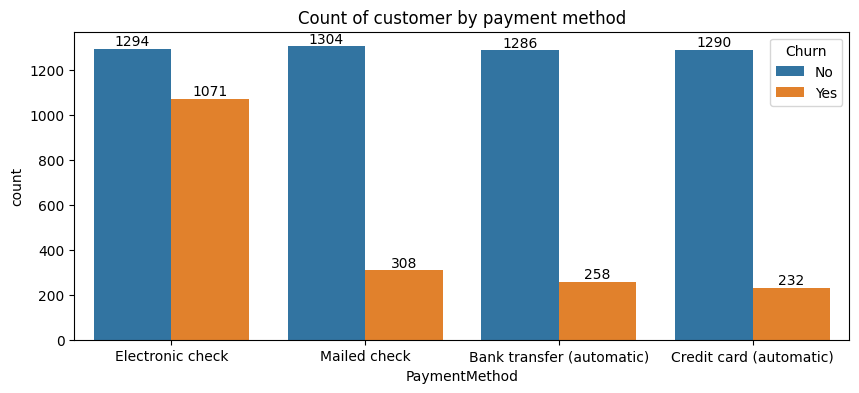

In [ ]:
plt.figure(figsize = (10,4))
ax = sns.countplot(x = 'PaymentMethod', data=pg, hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Count of customer by payment method')

In [ ]:
pg

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,no,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,no,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,no,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
#Customers on month-to-month contracts, using fiber optic internet, electronic check payments, and without security/support services show the highest churn.
#Churn is much lower for customers with 1–2 year contracts, OnlineSecurity/TechSupport, and automatic payment methods.
#Add-on protection services and long-term contracts are the strongest drivers of customer retention.